# AI for Chemistry — Week 02, Session A
## pandas dataframes, and molecules in code (SMILES, RDKit, descriptors)

**Course:** AI for Chemistry · **Session:** 02A (interleaved lecture + lab,
2.5 h) · **Runtime:** < 30 s, no GPU.

### Suggested timing (solo study, ~115 min)

| Section | Topic | Time |
|--------:|-------|-----:|
| 0 | Setup | 3 min |
| 1 | DataFrames: load and inspect | 15 min |
| 2 | Select, filter, sort | 20 min |
| 3 | New columns and `groupby` | 15 min |
| 4 | SMILES and RDKit molecule objects | 20 min |
| 5 | Molecular descriptors | 20 min |
| 6 | Exercises (4) | 22 min |

### Learning objectives
1. Load a CSV into a `DataFrame`; inspect it with `head`, `info`, `describe`,
   `shape`, `dtypes`. *(LO1)*
2. Select and filter rows/columns with `[]`, `.loc`, `.iloc` and boolean masks;
   sort; aggregate with `groupby`. *(LO1)*
3. Convert SMILES → RDKit `Mol`, produce **canonical** SMILES, draw molecules,
   and detect invalid SMILES. *(LO2)*
4. Compute descriptors (MW, logP, TPSA, HBD, HBA, rotatable bonds) and add them
   as dataframe columns. *(LO2)*

### Prerequisites — before this notebook you should be able to
- Use NumPy arrays, `for` loops, functions and matplotlib (Week 01).
- Recall what **logP**, **hydrogen-bond donors/acceptors**, **polar surface
  area** and **aqueous solubility** mean chemically.

### How to use this notebook (solo study)
Read each markdown cell, run the code cell under it, check the "what to look
for" note, and clear every **✅ Check yourself** cell before moving on. This is
the **solutions** notebook.

### Dataset — ESOL (Delaney)
`esol_delaney.csv`: 1128 organic molecules with **measured** aqueous solubility
(log S, mol L⁻¹), their SMILES, and a few precomputed properties. It is the
standard beginner solubility-regression benchmark and we reuse it in Week 03.


---
## 0. Setup

Import pandas (`pd`), NumPy, matplotlib and the RDKit pieces we need, and locate
the dataset. RDKit prints parse warnings to the log; we lower its verbosity so
the notebook output stays readable.

**What to look for:** version numbers, and `esol_delaney.csv  OK`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Draw
RDLogger.DisableLog("rdApp.*")          # silence RDKit's C++ log spam

ROOT = Path.cwd()
while not (ROOT / "sources").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "sources" / "datasets"
FIGDIR = ROOT / "lectures" / "week-02_data-and-molecules" / "slides" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

print("pandas", pd.__version__, "| rdkit", Chem.rdBase.rdkitVersion)
print("esol_delaney.csv", "OK" if (DATA / "esol_delaney.csv").is_file() else "MISSING")


pandas 3.0.5 | rdkit 2026.03.5
esol_delaney.csv OK


> **Common errors — Setup**
> - `ModuleNotFoundError: No module named 'rdkit'` — wrong kernel; select
>   *Python 3 (ai4chem)*.
> - RDKit version prints like `2026.03.x`; the exact patch number does not
>   matter for this notebook.


---
## 1. DataFrames: load and inspect

A **`DataFrame`** is a table: named columns, each a typed column vector
(a `Series`), sharing one row index. `pd.read_csv` builds one from a file.

The ESOL column names contain spaces and long phrases; we strip surrounding
whitespace and keep the originals otherwise (renaming is Exercise-free here).

**What to look for:** `(1128, 10)` — 1128 molecules, 10 columns; `dtypes`
showing `float64` for the numeric properties and `object`/`string` for
`Compound ID` and `smiles`.


In [2]:
esol = pd.read_csv(DATA / "esol_delaney.csv")
esol.columns = esol.columns.str.strip()          # tidy header whitespace

print("shape:", esol.shape)
print(esol.dtypes)
esol.head(3)


shape: (1128, 10)
Compound ID                                            str
ESOL predicted log solubility in mols per litre    float64
Minimum Degree                                       int64
Molecular Weight                                   float64
Number of H-Bond Donors                              int64
Number of Rings                                      int64
Number of Rotatable Bonds                            int64
Polar Surface Area                                 float64
measured log solubility in mols per litre          float64
smiles                                                 str
dtype: object


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)


`describe()` summarises every numeric column (count, mean, std, min, quartiles,
max). The target column is
`"measured log solubility in mols per litre"` — call it **log S**.

**What to look for:** log S ranges from about **-11.6** (essentially insoluble)
to **+1.6** (very soluble), mean ≈ **-3.05**. Molecular weight spans ~16 to
~780 g mol⁻¹.


In [3]:
TARGET = "measured log solubility in mols per litre"
esol.describe().round(2)


,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00
mean,-2.99,1.06,203.94,0.70,1.39,2.18,34.87,-3.05
std,1.68,0.24,102.74,1.09,1.32,2.64,35.38,2.10
min,-9.70,0.00,16.04,0.00,0.00,0.00,0.00,-11.60
25%,-3.95,1.00,121.18,0.00,0.00,0.00,0.00,-4.32
50%,-2.87,1.00,182.18,0.00,1.00,1.00,26.30,-2.86
75%,-1.84,1.00,270.37,1.00,2.00,3.00,55.44,-1.60
max,1.09,2.00,780.95,11.00,8.00,23.00,268.68,1.58


> **Common errors — Section 1**
> - `FileNotFoundError` — `DATA` points to the wrong place; print `DATA` and
>   check the path exists.
> - `KeyError` on a column — names still have stray spaces or different casing;
>   print `list(esol.columns)`.
> - `esol.head` (no parentheses) prints the *method*, not the rows.


### ✅ Check yourself — Section 1

Prints `Section 1 OK`. 1128 rows × 10 columns; mean log S ≈ -3.05.


In [4]:
# --- checkpoint (do not edit) ---
assert esol.shape == (1128, 10)
assert TARGET in esol.columns
assert abs(esol[TARGET].mean() - (-3.05)) < 0.01
assert esol[TARGET].min() < -11 and esol[TARGET].max() > 1.5
print("Section 1 OK")


Section 1 OK


**Conceptual questions**


1. Why is solubility reported as $\log S$ rather than $S$ itself?
2. `describe()` shows `count = 1128` for every numeric column. What would a
   smaller count tell you?


**Answers**


1. Solubility spans many orders of magnitude (here ~13 decades); a log scale
   makes the distribution roughly symmetric, gives errors a consistent
   meaning (a factor, not an absolute amount), and matches how solubility
   enters thermodynamic relationships ($\Delta G \propto \ln S$).
2. A count below 1128 means that column has missing values (`NaN`) in some
   rows — something we must handle before modelling (Week 02B).


---
## 2. Select, filter and sort

- `esol["smiles"]` — one column (a `Series`).
- `esol[["Compound ID", TARGET]]` — several columns (a `DataFrame`).
- `esol.loc[mask, cols]` — rows where a **boolean mask** is `True`.
- `esol.iloc[0:3]` — rows by integer position.
- `esol.sort_values(TARGET)` — sorted copy.

Chemistry question: **which compounds are the most and least water-soluble?**

**What to look for:** the least soluble entries are large, greasy, polycyclic
molecules (high logP, many rings); the most soluble are small polar ones.


In [5]:
least_soluble = esol.sort_values(TARGET).head(5)[["Compound ID", TARGET, "smiles"]]
most_soluble = esol.sort_values(TARGET).tail(5)[["Compound ID", TARGET, "smiles"]]
print("LEAST soluble:\n", least_soluble.to_string(index=False))
print("\nMOST soluble:\n", most_soluble.to_string(index=False))


LEAST soluble:
                  Compound ID  measured log solubility in mols per litre                                                smiles
2,2',3,3',4,4',5,5',6,6'-PCB                                    -11.600 Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(Cl)c2Cl 
                    Coronene                                     -9.332                c1cc2ccc3ccc4ccc5ccc6ccc1c7c2c3c4c5c67
     2,2',3,3',4,4',5,5'-PCB                                     -9.160          Clc1cc(c(Cl)c(Cl)c1Cl)c2cc(Cl)c(Cl)c(Cl)c2Cl
     2,2',3,3',5,5',6,6'-PCB                                     -9.150         Clc1cc(Cl)c(Cl)c(c1Cl)c2c(Cl)c(Cl)cc(Cl)c2Cl 
          Benzo[ghi]perylene                                     -9.018                  c1cc2ccc3ccc4ccc5cccc6c(c1)c2c3c4c56

MOST soluble:
      Compound ID  measured log solubility in mols per litre                       smiles
        Glycerol                                      1.120                     OCC(O)CO
     vamidothion                  

A **boolean mask** is a `Series` of `True`/`False`. Combine conditions with
`&` (and), `|` (or), each condition in parentheses. Here: molecules that are
both **heavy** (MW > 400) and **very insoluble** (log S < -5).

**What to look for:** a few dozen rows; every one has `Molecular Weight > 400`
and `log S < -5`.


In [6]:
mask = (esol["Molecular Weight"] > 400) & (esol[TARGET] < -5)
heavy_insoluble = esol.loc[mask, ["Compound ID", "Molecular Weight", TARGET]]
print(heavy_insoluble.shape[0], "molecules match")
heavy_insoluble.head()


22 molecules match


,Compound ID,Molecular Weight,measured log solubility in mols per litre
60,"2,2',3,3',5,5',6,6'-PCB",429.772,-9.150
86,Flucythrinate,451.469,-6.876
127,Cyfluthrin,434.294,-7.337
158,Iodofenphos,413.000,-6.620
167,3-Octanoyloxymethylphenytoin,408.498,-6.523


> **Common errors — Section 2**
> - `ValueError: The truth value of a Series is ambiguous` — you used `and`/`or`
>   instead of `&`/`|`, or forgot parentheses around each comparison.
> - Chained indexing `esol[mask]["x"] = ...` may not write back — use
>   `esol.loc[mask, "x"] = ...`.
> - `sort_values` returns a **new** dataframe; the original is unchanged unless
>   you reassign or pass `inplace=True`.


### ✅ Check yourself — Section 2

Prints `Section 2 OK`. Every matched molecule satisfies both conditions; the first row of the sorted table is the global minimum.


In [7]:
# --- checkpoint (do not edit) ---
assert list(least_soluble["Compound ID"].iloc[:1])          # non-empty
assert (heavy_insoluble["Molecular Weight"] > 400).all()
assert (esol.loc[mask, TARGET] < -5).all()
assert esol.sort_values(TARGET).iloc[0][TARGET] == esol[TARGET].min()
print("Section 2 OK")


Section 2 OK


**Conceptual questions**


1. Why parentheses around `(esol["Molecular Weight"] > 400)` before the `&`?
2. `esol.iloc[0]` and `esol.loc[0]` return the same row here. When would they
   differ?


**Answers**


1. `&` binds tighter than `>` in Python, so without parentheses
   `400 & esol[TARGET]` is evaluated first and raises. Parentheses force each
   comparison to complete before the element-wise `&`.
2. `.iloc` is *positional* (0 = first row); `.loc` is *label-based* (0 = the
   row whose index label is 0). They coincide only while the index is the
   default `0..n-1`. After filtering or sorting, `.loc[0]` still finds label 0
   but `.iloc[0]` finds whatever is now on top.


---
## 3. New columns and `groupby`

Assigning to a new key adds a column. `groupby(key)` splits the table into
groups sharing a value of `key`, and an aggregation (`mean`, `count`, ...)
collapses each group to one number.

Chemistry question: **does aqueous solubility fall as a molecule gains rings?**
More rings usually means more rigid, aromatic, hydrophobic surface.

**What to look for:** mean log S drops steadily from ~-1.9 (acyclic) to ~-7 at
6 rings, then wobbles where only a handful of molecules exist.


In [8]:
by_rings = (esol.groupby("Number of Rings")[TARGET]
            .agg(["mean", "count"]).round(2))
print(by_rings)


                 mean  count
Number of Rings             
0               -1.91    317
1               -2.55    386
2               -3.96    221
3               -4.38    116
4               -4.84     63
5               -6.76     16
6               -7.10      4
7               -5.61      3
8               -4.69      2


A quick scatter of solubility against the dataset's polar surface area, with
point colour showing the number of rotatable bonds. matplotlib reads columns
straight out of the dataframe.

**What to look for:** a broad downward trend (more polar surface → more
soluble is *not* what you see here — PSA alone is a weak predictor), lots of
scatter. We quantify predictors properly in Week 03.


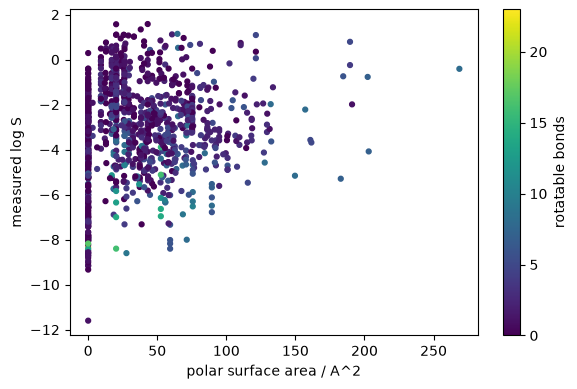

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(esol["Polar Surface Area"], esol[TARGET],
                c=esol["Number of Rotatable Bonds"], s=12, cmap="viridis")
ax.set_xlabel("polar surface area / A^2"); ax.set_ylabel("measured log S")
fig.colorbar(sc, label="rotatable bonds")
fig.tight_layout(); fig.savefig(FIGDIR / "solubility_vs_psa.png", dpi=200)
plt.show()


> **Common errors — Section 3**
> - `SettingWithCopyWarning` — you assigned into a *slice*. Build columns on the
>   full frame, or take an explicit `.copy()` first.
> - `groupby(...).mean()` on a frame with text columns errors in recent pandas —
>   select the numeric column(s) first, as above.


### ✅ Check yourself — Section 3

Prints `Section 3 OK`. `by_rings` has `mean`/`count` columns and the 0→6 ring means are strictly decreasing.


In [10]:
# --- checkpoint (do not edit) ---
assert list(by_rings.columns) == ["mean", "count"]
# solubility decreases monotonically over the well-populated 0..6 ring range
means_0_6 = by_rings.loc[0:6, "mean"].values
assert all(np.diff(means_0_6) < 0)
assert (FIGDIR / "solubility_vs_psa.png").is_file()
print("Section 3 OK")


Section 3 OK


**Conceptual questions**


1. The 7- and 8-ring groups break the trend. Why treat those means with
   caution?
2. Would `groupby` on a *continuous* column like `Molecular Weight` be useful
   as written? What would you do instead?


**Answers**


1. Their `count` is tiny (single digits), so the group mean has a large
   standard error and is dominated by the idiosyncrasies of a few molecules.
2. No — almost every value is unique, so each group has one row. You would
   **bin** the column first (`pd.cut(esol["Molecular Weight"], bins=...)`) and
   group on the bin label.


---
## 4. SMILES and RDKit molecule objects

A **SMILES** string encodes a molecular graph as text (`CCO` = ethanol,
`c1ccccc1` = benzene, lower case = aromatic). `Chem.MolFromSmiles(s)` parses it
into a `Mol` object (atoms, bonds, rings); on failure it returns **`None`** and
does **not** raise.

The *same* molecule can be written many ways. `Chem.MolToSmiles(mol)` returns
the unique **canonical** SMILES — essential for comparing or deduplicating.

**What to look for:** three spellings of ethanol all canonicalise to `CCO`;
the nonsense string yields `None`.


In [11]:
for s in ["CCO", "OCC", "C(O)C", "this-is-not-smiles"]:
    mol = Chem.MolFromSmiles(s)
    canon = Chem.MolToSmiles(mol) if mol is not None else "INVALID"
    print(f"{s:20s} -> {canon}")


CCO                  -> CCO
OCC                  -> CCO
C(O)C                -> CCO
this-is-not-smiles   -> INVALID


Draw the five least-soluble molecules as a grid. Structure makes the trend
obvious: fused aromatic rings, halogens, little polar functionality.

**What to look for:** an image of 5 structures; note how "greasy" they look.


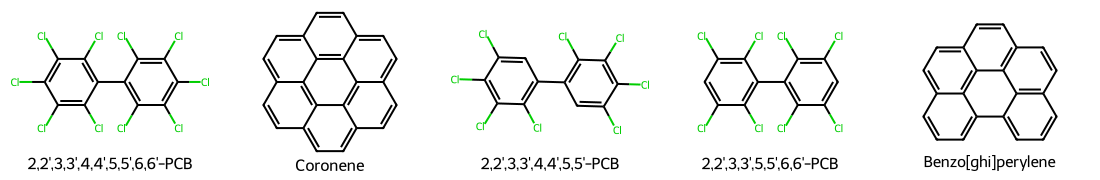

In [12]:
worst_smiles = esol.sort_values(TARGET).head(5)["smiles"].tolist()
worst_mols = [Chem.MolFromSmiles(s) for s in worst_smiles]
worst_names = esol.sort_values(TARGET).head(5)["Compound ID"].tolist()
img = Draw.MolsToGridImage(worst_mols, legends=worst_names, molsPerRow=5,
                           subImgSize=(220, 180), returnPNG=False)  # PIL image
img.save(FIGDIR / "least_soluble_grid.png")
img


> **Common errors — Section 4**
> - Forgetting the `None` check — `Chem.MolToSmiles(None)` raises `TypeError`.
>   Always guard: `if mol is not None:`.
> - Aromatic vs Kekulé: `c1ccccc1` and `C1=CC=CC=C1` both parse; canonical
>   SMILES picks one form for you.
> - `Draw.MolsToGridImage` needs a list of `Mol`, not SMILES strings.


### ✅ Check yourself — Section 4

Prints `Section 4 OK`. All ethanol spellings → `CCO`; the invalid string → `None`; the grid image is saved.


In [13]:
# --- checkpoint (do not edit) ---
assert Chem.MolToSmiles(Chem.MolFromSmiles("OCC")) == "CCO"
assert Chem.MolToSmiles(Chem.MolFromSmiles("C(O)C")) == "CCO"
assert Chem.MolFromSmiles("this-is-not-smiles") is None
assert all(m is not None for m in worst_mols)
assert (FIGDIR / "least_soluble_grid.png").is_file()
print("Section 4 OK")


Section 4 OK


**Conceptual questions**


1. Why can two different SMILES strings be the same molecule, and how does a
   canonical algorithm resolve it?
2. `Chem.MolFromSmiles` returning `None` instead of raising is a deliberate
   design choice. What must *your* code therefore always do?


**Answers**


1. SMILES encodes a graph traversal, and a graph has many valid traversals
   (different starting atom, branch order). A canonical algorithm computes a
   unique atom ranking (a Morgan-type canonical labelling) and always starts
   and branches the same way, giving one string per molecule.
2. Check for `None` after every parse and decide what to do with failures
   (drop the row, log it) — never assume a SMILES column is all valid.


---
## 5. Molecular descriptors

A **descriptor** is a number computed from structure. The classic
"drug-likeness" set (Lipinski / ADME):

| Descriptor | RDKit call | Measures |
|---|---|---|
| Molecular weight | `Descriptors.MolWt` | size |
| logP | `Descriptors.MolLogP` | lipophilicity (Crippen estimate) |
| TPSA | `Descriptors.TPSA` | polar surface area (Å²) |
| H-bond donors | `Descriptors.NumHDonors` | e.g. –OH, –NH |
| H-bond acceptors | `Descriptors.NumHAcceptors` | e.g. O, N lone pairs |
| Rotatable bonds | `Descriptors.NumRotatableBonds` | flexibility |

We compute them for every molecule and attach them as columns with `.apply`.

**What to look for:** a helper that returns `None` for bad SMILES; new columns
`MolWt, MolLogP, ...`; RDKit's `MolWt` agreeing closely with the dataset's own
`Molecular Weight` column.


In [14]:
def descriptor_row(smiles):
    """dict of six descriptors for a SMILES, or NaNs if it will not parse."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {k: np.nan for k in
                ["MolWt", "MolLogP", "TPSA", "NumHDonors", "NumHAcceptors",
                 "NumRotatableBonds"]}
    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),
        "NumRotatableBonds": Descriptors.NumRotatableBonds(mol),
    }

desc = pd.DataFrame(list(esol["smiles"].apply(descriptor_row)))
esol_desc = pd.concat([esol, desc], axis=1)          # glue columns side by side
esol_desc[["Compound ID", "MolWt", "MolLogP", "TPSA", "NumHDonors"]].head()


,Compound ID,MolWt,MolLogP,TPSA,NumHDonors
0,Amigdalin,457.432,-3.10802,202.32,7
1,Fenfuram,201.225,2.84032,42.24,1
2,citral,152.237,2.87800,17.07,0
3,Picene,278.354,6.29940,0.00,0
4,Thiophene,84.143,1.74810,0.00,0


Sanity-check the computed `MolWt` against the dataset's precomputed
`Molecular Weight`. They use slightly different atomic-weight tables, so expect
agreement to a fraction of a percent, not exact equality.

**What to look for:** correlation ≈ 1.000 and a mean absolute difference well
below 1 g mol⁻¹.


corr : 1.0
mean |difference| : 0.0 g/mol


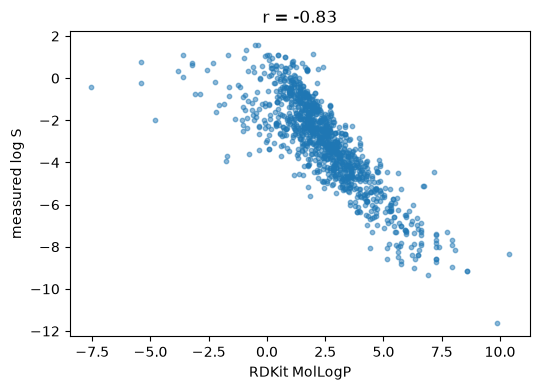

In [15]:
diff = (esol_desc["MolWt"] - esol_desc["Molecular Weight"]).abs()
print("corr :", round(esol_desc["MolWt"].corr(esol_desc["Molecular Weight"]), 4))
print("mean |difference| :", round(diff.mean(), 3), "g/mol")

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(esol_desc["MolLogP"], esol_desc[TARGET], s=10, alpha=0.5)
ax.set_xlabel("RDKit MolLogP"); ax.set_ylabel("measured log S")
ax.set_title(f"r = {esol_desc['MolLogP'].corr(esol_desc[TARGET]):.2f}")
fig.tight_layout(); fig.savefig(FIGDIR / "solubility_vs_logp.png", dpi=200)
plt.show()


> **Common errors — Section 5**
> - `.apply(descriptor_row)` returns a `Series` of dicts; wrap in
>   `pd.DataFrame(list(...))` to expand to columns.
> - `pd.concat(..., axis=1)` misaligns if the two frames have different indexes
>   — reset both or make sure they match (they do here).
> - `Descriptors.MolLogP` is an *estimate* (Crippen contributions), not a
>   measured value; treat it as a feature, not ground truth.


### ✅ Check yourself — Section 5

Prints `Section 5 OK`. RDKit vs dataset MW correlate > 0.999; logP vs log S correlation is about -0.7.


In [16]:
# --- checkpoint (do not edit) ---
assert {"MolWt", "MolLogP", "TPSA", "NumHDonors"}.issubset(esol_desc.columns)
assert esol_desc["MolWt"].corr(esol_desc["Molecular Weight"]) > 0.999
assert (esol_desc["MolWt"] - esol_desc["Molecular Weight"]).abs().mean() < 1.0
# lipophilicity is anti-correlated with solubility
assert esol_desc["MolLogP"].corr(esol_desc[TARGET]) < -0.5
assert (FIGDIR / "solubility_vs_logp.png").is_file()
print("Section 5 OK")


Section 5 OK


**Conceptual questions**


1. logP correlates with log S at about $r=-0.7$. Why the minus sign, and why
   not $-1$?
2. Give one reason the dataset's `Molecular Weight` and RDKit's `MolWt` differ
   at all.


**Answers**


1. Lipophilic (high-logP) molecules resist dissolving in water, so higher logP
   means lower solubility — hence negative. It is not $-1$ because size,
   crystal-packing (melting point), hydrogen bonding and ionisation also
   matter; logP explains roughly half the variance ($r^2\approx0.5$).
2. Different standard atomic weights / isotope conventions, and whether
   implicit hydrogens are counted with average or most-abundant isotope mass.
   The differences are sub-gram-per-mole.


---
## 6. Exercises

Blank bodies in the `_student` notebook; the `assert` cells are identical in
both versions.


### Exercise 1 — filter and count *(easy, ~8 min)*

Write `poorly_soluble(df, threshold=-5.0)` returning the sub-DataFrame of rows
whose measured log S is **below** `threshold`. Use it to make `insoluble` and
report how many molecules that is.

<details><summary>Show hint</summary>

`return df.loc[df[TARGET] < threshold]`. `TARGET` is defined in Section 1.
There are a few hundred such molecules.
</details>


In [17]:
def poorly_soluble(df, threshold=-5.0):
    """Rows whose measured log S is below `threshold`."""
    return df.loc[df[TARGET] < threshold]

insoluble = poorly_soluble(esol)
print(len(insoluble), "molecules with log S < -5")


180 molecules with log S < -5


In [18]:
# --- check your answer (do not edit) ---
assert (insoluble[TARGET] < -5.0).all()
assert len(poorly_soluble(esol, -3.0)) > len(insoluble)
assert len(poorly_soluble(esol, -100.0)) == 0
print("Exercise 1 OK")


Exercise 1 OK


### Exercise 2 — a descriptor for one molecule *(medium, ~12 min)*

Write `lipinski_flags(smiles)` returning a dict with keys
`mw, logp, hbd, hba` and a boolean `passes_ro5` that is `True` when **at most
one** of the four Lipinski rules is violated (MW ≤ 500, logP ≤ 5, HBD ≤ 5,
HBA ≤ 10). Test it on caffeine.

<details><summary>Show hint</summary>

Parse, compute the four descriptors, count how many thresholds are exceeded
(`sum([...])`), and set `passes_ro5 = n_violations <= 1`.
Caffeine: MW ≈ 194, logP ≈ -1.0 → passes.
</details>


In [19]:
def lipinski_flags(smiles):
    """Lipinski Ro5 descriptors and pass/fail for a SMILES."""
    mol = Chem.MolFromSmiles(smiles)
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    n_violations = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    return {"mw": mw, "logp": logp, "hbd": hbd, "hba": hba,
            "passes_ro5": n_violations <= 1}

caffeine = lipinski_flags("Cn1cnc2n(C)c(=O)n(C)c(=O)c12")
print(caffeine)


{'mw': 194.19399999999996, 'logp': -1.0293, 'hbd': 0, 'hba': 3, 'passes_ro5': True}


In [20]:
# --- check your answer (do not edit) ---
assert set(caffeine) == {"mw", "logp", "hbd", "hba", "passes_ro5"}
assert caffeine["passes_ro5"] is True
assert 180 < caffeine["mw"] < 210
# a large lipophilic molecule should fail
assert lipinski_flags("C" * 40)["passes_ro5"] is False
print("Exercise 2 OK")


Exercise 2 OK


### Exercise 3 — group and compare *(medium, ~15 min)*

Add a column `hbd_bin` to `esol_desc` that is `"0"`, `"1"`, `"2"`, or `"3+"`
based on `NumHDonors`, then write `solubility_by_hbd(df)` returning a Series of
mean log S per bin (index order `["0", "1", "2", "3+"]`).

<details><summary>Show hint</summary>

`np.where` or a small function with `.apply`. For the aggregation:
`df.groupby("hbd_bin")[TARGET].mean().reindex(["0","1","2","3+"])`.
Broadly, more donors → more soluble: the `"3+"` mean sits well above the `"0"`
mean (though `"1"` and `"2"` are close).
</details>


In [21]:
def hbd_label(n):
    return "3+" if n >= 3 else str(int(n))

esol_desc["hbd_bin"] = esol_desc["NumHDonors"].apply(hbd_label)

def solubility_by_hbd(df):
    """Mean measured log S per hydrogen-bond-donor bin."""
    return (df.groupby("hbd_bin")[TARGET].mean()
              .reindex(["0", "1", "2", "3+"]))

hbd_solubility = solubility_by_hbd(esol_desc)
print(hbd_solubility.round(2))


hbd_bin
0    -3.47
1    -2.53
2    -2.61
3+   -2.17
Name: measured log solubility in mols per litre, dtype: float64


In [22]:
# --- check your answer (do not edit) ---
assert list(hbd_solubility.index) == ["0", "1", "2", "3+"]
assert hbd_solubility["3+"] > hbd_solubility["0"] + 1.0   # clear overall trend
assert hbd_solubility["1"] > hbd_solubility["0"]
assert set(esol_desc["hbd_bin"].unique()) <= {"0", "1", "2", "3+"}
print("Exercise 3 OK")


Exercise 3 OK


### Exercise 4 — canonicalisation and duplicates *(harder, ~18 min)*

Write `canonical_or_none(smiles)` (canonical SMILES or `None`) and use it to add
a `canonical_smiles` column to a **copy** of `esol`. Then compute
`n_duplicate_structures`: how many rows share a canonical SMILES with an
earlier row (i.e. `len(df) - df["canonical_smiles"].nunique()`, ignoring
`None`).

<details><summary>Show hint</summary>

`m = Chem.MolFromSmiles(s); return Chem.MolToSmiles(m) if m else None`.
ESOL has 1128 rows but only 1117 unique structures.
</details>


In [23]:
def canonical_or_none(smiles):
    """Canonical SMILES, or None if the input will not parse."""
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol) if mol is not None else None

esol_c = esol.copy()
esol_c["canonical_smiles"] = esol_c["smiles"].apply(canonical_or_none)
valid = esol_c["canonical_smiles"].dropna()
n_duplicate_structures = len(valid) - valid.nunique()
print("duplicate structures:", n_duplicate_structures)


duplicate structures: 11


In [24]:
# --- check your answer (do not edit) ---
assert canonical_or_none("OCC") == "CCO"
assert canonical_or_none("xyz") is None
assert n_duplicate_structures == 11
assert esol_c["canonical_smiles"].notna().all()   # ESOL has no invalid SMILES
print("Exercise 4 OK")


Exercise 4 OK


---
## Summary — what you learned

- **pandas**: `read_csv`, `head`/`info`/`describe`, column and `.loc`/`.iloc`
  selection, boolean filtering, `sort_values`, new columns, `groupby` + `agg`.
- **SMILES ↔ RDKit**: `MolFromSmiles` (returns `None` on failure),
  `MolToSmiles` (canonical), `Draw.MolsToGridImage`.
- **Descriptors**: MW, logP, TPSA, HBD, HBA, rotatable bonds via
  `rdkit.Chem.Descriptors`, attached to a dataframe with `.apply`.
- A molecule is now a **row of numbers** — exactly what a machine-learning model
  consumes.

Week 02B turns this into a disciplined pipeline: clean the data, featurise with
fingerprints, and look at the chemical space.


## Further reading (course source list only)

- SciCompforChemists ch. 5 (pandas):
  <https://weisscharlesj.github.io/SciCompforChemists/notebooks/chapter_05/chap_05_notebook.html>
- EPFL *AI for Chemistry* 01b (pandas) and 01d (RDKit basics):
  <https://colab.research.google.com/github/schwallergroup/ai4chem_course/blob/main/notebooks/01%20-%20Basics/01b_python_essentials_pandas.ipynb>,
  <https://colab.research.google.com/github/schwallergroup/ai4chem_course/blob/main/notebooks/01%20-%20Basics/01d_rdkit_basics.ipynb>
- TeachOpenCADD **T002** (compound ADME / Lipinski Ro5):
  <https://projects.volkamerlab.org/teachopencadd/talktorials/T002_compound_adme.html>


## Attribution

Original teaching material for *AI for Chemistry*, adapted and rewritten from:

- **Scientific Computing for Chemists with Python** (C. J. Weiss) — pandas
  pedagogy. CC-BY-NC-SA 4.0. <https://github.com/weisscharlesj/SciCompforChemists>
- **TeachOpenCADD** (Volkamer Lab) — talktorial T002, the Lipinski Ro5
  descriptor workflow. CC-BY 4.0.
  <https://github.com/volkamerlab/teachopencadd>
- **EPFL CH-457 *AI for Chemistry*** (Schwaller group) — RDKit-basics framing.
  MIT licence. <https://github.com/schwallergroup/ai4chem_course>

Dataset: ESOL / Delaney aqueous solubility (`esol_delaney.csv`), downloaded from
the DeepChem data mirror with a pinned SHA-256. Originally from Delaney,
*J. Chem. Inf. Comput. Sci.* 2004 — `TODO(verify)` the citation before use in
an assessed context. No verbatim text is reproduced from the sources above.
